<a href="https://colab.research.google.com/github/christabel-sky01/Adidas-sale-dashboard/blob/main/NetflixAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Netflix data set.xlsx to Netflix data set.xlsx


In [3]:
import os

print(os.listdir())

['.config', 'Netflix data set.xlsx', 'sample_data']


In [4]:
import pandas as pd

df = pd.read_excel('/content/Netflix data set.xlsx')

# View the first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25 00:00:00,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
# Check dimensions
print("Rows and Columns:", df.shape)

Rows and Columns: (8807, 12)


In [7]:
# Summary statistics
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8804,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,2026-02-09 00:00:00,Rajiv Chilaka,David Attenborough,United States,2020-01-01 00:00:00,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,2,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [10]:
# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

# Drop rows with missing date_added
df = df.dropna(subset=['date_added'])

In [11]:
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract year added
df['year_added'] = df['date_added'].dt.year

In [12]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate rows: 0


In [13]:
df.to_excel('cleaned_netflix_dataset.xlsx', index=False)

Exploratory Data Analysis


In [14]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2666


In [15]:
df['year_added'].value_counts().sort_index()

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,429


In [16]:
country_counts = df['country'].str.split(', ').explode().value_counts()

country_counts.head(10)

,count
country,
United States,3683
India,1046
Unknown,830
United Kingdom,803
Canada,445
France,393
Japan,317
Spain,232
South Korea,231


In [17]:
df['rating'].value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


In [18]:
genre_counts = df['listed_in'].str.split(', ').explode().value_counts()

genre_counts.head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1350
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


Data Visualization

In [19]:
import matplotlib.pyplot as plt

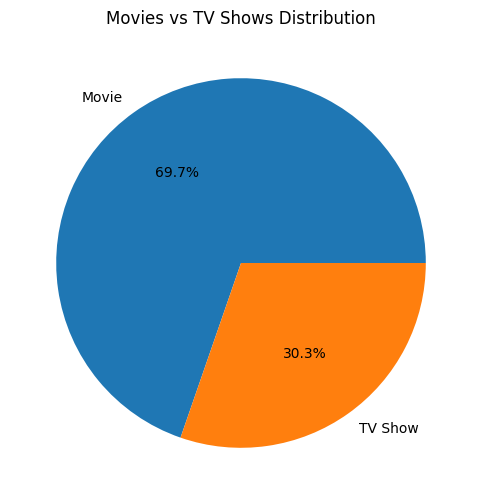

In [20]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Movies vs TV Shows Distribution')
plt.ylabel('')
plt.show()

Finding:

Movies make up a larger proportion of Netflix content compared to TV Shows.

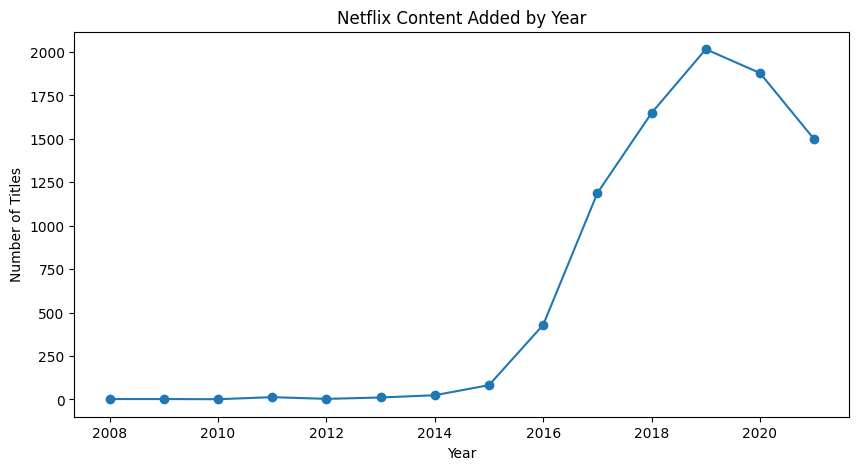

In [21]:
df['year_added'].value_counts().sort_index().plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title('Netflix Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

Finding:

Netflix experienced rapid content growth in recent years before showing signs of stabilization

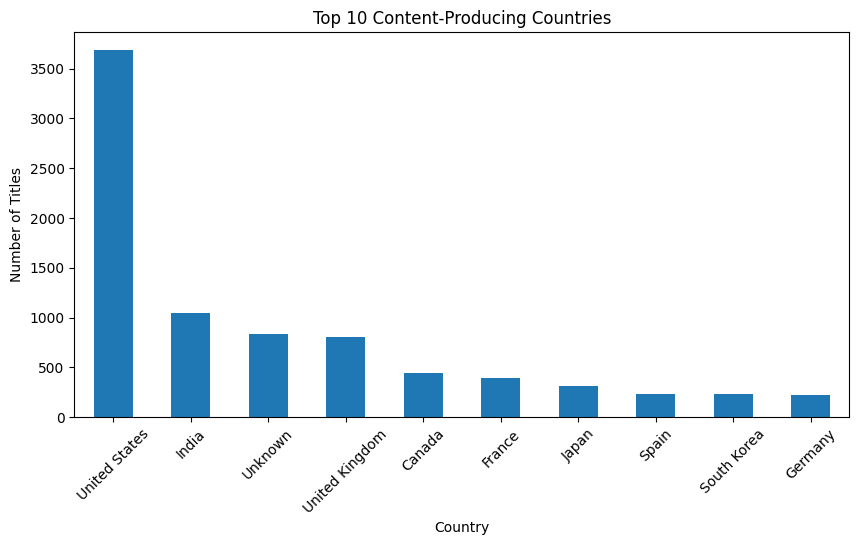

In [22]:
country_counts.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Content-Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

Finding:

The United States contributes the highest number of titles on Netflix.

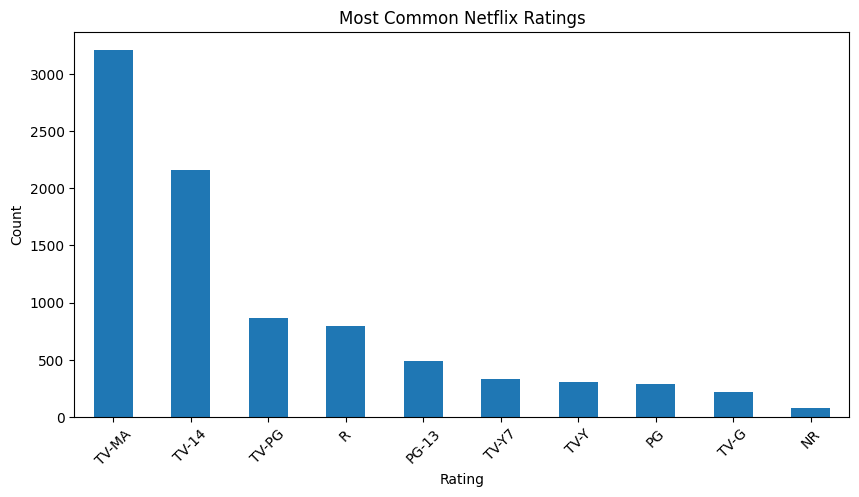

In [23]:
df['rating'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Most Common Netflix Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

Finding:

TV-MA and TV-14 are among the most frequent ratings, indicating a strong focus on mature audiences

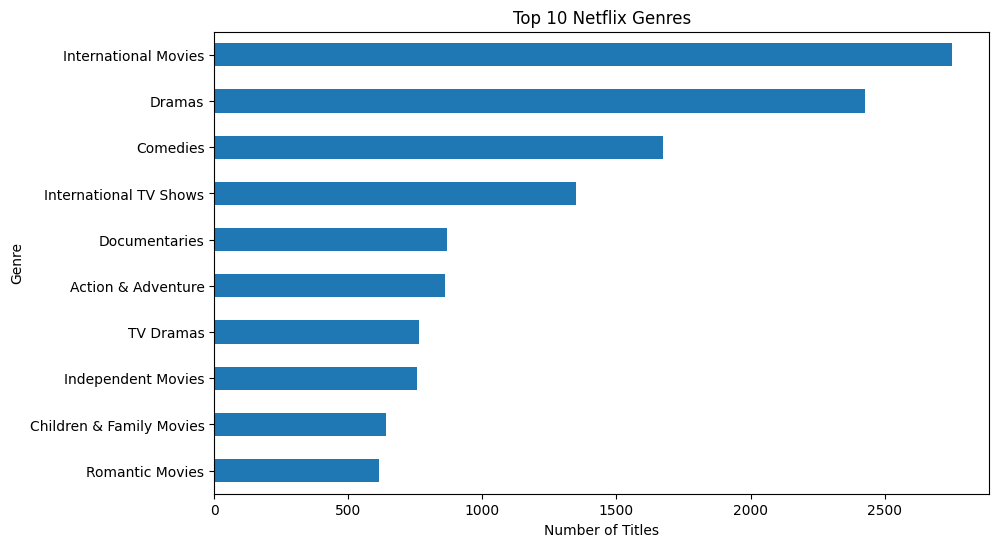

In [24]:
genre_counts.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

Finding:

International Movies, Dramas, and Comedies are among Netflix's most common categories

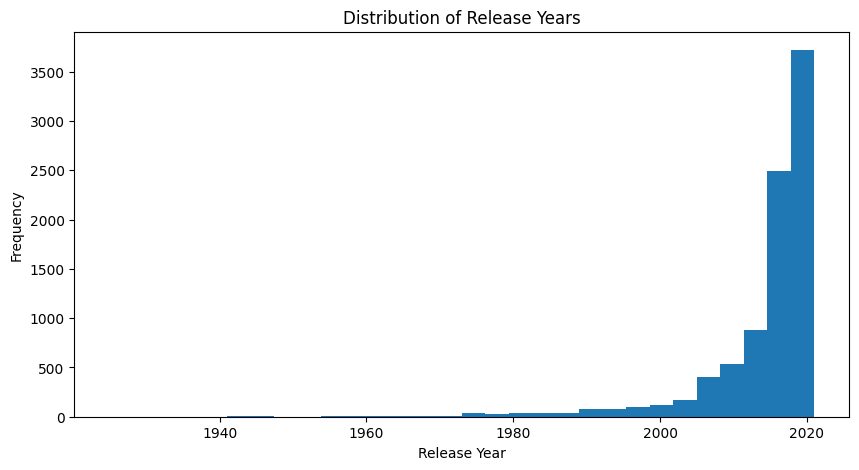

In [25]:
df['release_year'].plot(
    kind='hist',
    bins=30,
    figsize=(10,5)
)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show()

Finding:

Most Netflix titles were released in relatively recent years

Insight 1

The Movies vs TV Shows visualization shows that movies dominate Netflix's catalog, suggesting Netflix places greater emphasis on film content.

Insight 2

The Content Added by Year chart reveals a substantial increase in titles added from around 2016 onwards, reflecting Netflix's aggressive expansion strategy.

Insight 3

The Top Producing Countries chart indicates that the United States is Netflix's largest content contributor, followed by countries such as India and the United Kingdom.

Insight 4

The Ratings visualization demonstrates that Netflix primarily targets teen and adult audiences, with TV-MA and TV-14 appearing most frequently.

Insight 5

The Genre analysis highlights the platform's strong focus on international and drama-based content, reflecting Netflix's global audience strategy.

Netflix Dataset Summary Report

Cleaning Challenges Encountered:

* Missing values were identified in the director, cast, country, rating, and date_added columns.
* The date_added field required conversion to datetime format for temporal analysis.
* Some country and genre entries contained multiple values separated by commas, requiring splitting for accurate analysis.
* Duplicate records were checked and removed to maintain data quality.

Key EDA Findings:

* Movies constitute the majority of Netflix's content library.
* The number of titles added to Netflix increased significantly over time, particularly from 2016 onward.
* The United States emerged as the leading producer of Netflix content.
* TV-MA and TV-14 were the most common audience ratings.
* International Movies and Drama categories appeared most frequently among Netflix titles.

Top Insights:

1. Netflix emphasizes movie content more heavily than television programming.
2. The platform expanded its content offerings rapidly during the late 2010s.
3. Content production is heavily concentrated in a few countries, especially the United States.
4. Netflix's catalog is largely designed for teen and adult viewers.
5. Diverse international genres contribute substantially to the platform's global appeal.
